# 02 Labels - Gold, Silver, And Final Label Coverage

Purpose: inspect manual gold-label coverage, weak/silver labels, final labels, and where labeled examples are concentrated.


In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)
plt.style.use('default')

DATA_DIR = Path('../data') if Path('../data').exists() else Path('data')
RAW_PATH = DATA_DIR / 'data.parquet'
TRAIN_PATH = DATA_DIR / 'train.parquet'
TEST_PATH = DATA_DIR / 'test.parquet'
DATASET_PATH = DATA_DIR / 'dataset.parquet'
GOLD_PATH = DATA_DIR / 'gold_labels.parquet'

import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [3]:
train = pd.read_parquet("../data/train.parquet")
test = pd.read_parquet("../data/test.parquet")
clean = pd.concat([train, test], ignore_index=True)

clean

,id,message_id,date,sender,to,cc,bcc,subject,body,x_from,...,x_filename,source_file,thread_id,parent_id,sequence,is_forward,is_reply,sender_domain,recipient_domain,gold_labels
0,109782,<5514598.1075862425400.JavaMail.evans@thyme>,2001-11-07 15:49:19+00:00,lindy.donoho@enron.com,[kathy.campos@enron.com],[tracy.geaccone@enron.com],[tracy.geaccone@enron.com],spreadsheet for mtg this morning,Please print a few copies of this spreadsheet ...,"Donoho, Lindy </O=ENRON/OU=NA/CN=RECIPIENTS/CN...",...,TGEACCO (Non-Privileged).pst,data/extracted/maildir/geaccone-t/inbox/446.,0049263cdf374df3a0b8353d6fc573d12aa09842389bf0...,NaN,1,False,False,enron.com,[enron.com],NaN
1,206201,<16813213.1075846930667.JavaMail.evans@thyme>,2000-02-17 17:50:00+00:00,molly.harris@enron.com,"[frank.davis@enron.com, karen.lambert@enron.co...","[bernice.rodriguez@enron.com, bhautik.patel@en...","[bernice.rodriguez@enron.com, bhautik.patel@en...",eol credit responses 2/17,Please find attached Credit's EOL responses fo...,Molly Harris,...,tjones.nsf,data/extracted/maildir/jones-t/all_documents/864.,0049fe1c4b318dc877e04a5635d4d217f2a55ab0ea578e...,NaN,1,False,False,enron.com,[enron.com],NaN
2,167049,<19985894.1075841997166.JavaMail.evans@thyme>,2001-06-26 23:35:31+00:00,rumaldo.lopez@enron.com,None,None,None,it meeting,\n\n--------- Inline attachment follows ------...,"Lopez, Rumaldo </O=ENRON/OU=NA/CN=RECIPIENTS/C...",...,stacy white 7-15-02.PST,data/extracted/maildir/white-s/calendar/144.,004a50081901a54101f96e52dae9c5ea5cbf24f406e144...,NaN,1,False,False,enron.com,[],NaN
3,50285,<2204368.1075847959885.JavaMail.evans@thyme>,2001-02-14 04:10:00+00:00,sgovenar@govadv.com,"[acomnes@enron.com, beverly.aden@enron.com, bh...",None,None,direct access,Two different sources have heard that Governor...,Scott Govenar <sgovenar@govadv.com>,...,skean.nsf,data/extracted/maildir/kean-s/calendar/untitle...,004a7cff7597737564b8e22ac09e90d5202ac531f8fc15...,NaN,1,False,False,govadv.com,"[enron.com, gmssr.com, govadv.com, lhom.com]",NaN
4,212696,<32367688.1075847028270.JavaMail.evans@thyme>,2000-10-23 11:28:00+00:00,gillian.johnson@enron.com,[tana.jones@enron.com],None,None,i2 technologies,---------------------- Forwarded by Gillian Jo...,Gillian Johnson,...,tjones.nsf,data/extracted/maildir/jones-t/all_documents/4...,004ade473ceeffea6bf4b6773cf7e6a08f91abfcfb857d...,NaN,1,False,True,enron.com,[enron.com],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129798,182888,<3410869.1075852334337.JavaMail.evans@thyme>,2001-10-25 15:49:43+00:00,kenneth.thibodeaux@enron.com,"[a..price@enron.com, a..shankman@enron.com, an...",None,None,erv notification: (violation/notification mem...,The report named: Violation/Notification Memo ...,"Thibodeaux, Kenneth </O=ENRON/OU=NA/CN=RECIPIE...",...,GWHALLE (Non-Privileged).pst,data/extracted/maildir/whalley-g/deleted_items...,002c06ab8074470f02cffa70d042efee11fa054d2dcd15...,NaN,1,False,False,enron.com,[enron.com],0.0
129799,164312,<6269615.1075857327838.JavaMail.evans@thyme>,2000-09-12 08:34:00+00:00,dgagliardi@reliantenergy.com,[clint.dean@enron.com],None,None,true orange fax/e-mail #86,---------------------- Forwarded by David M Ga...,dgagliardi@reliantenergy.com,...,cdean.nsf,data/extracted/maildir/dean-c/all_documents/114.,002fd122b83724284473b99e8b31d5adb786624fa070cf...,NaN,1,False,False,reliantenergy.com,[enron.com],0.0
129800,47191,<19246567.1075846268869.JavaMail.evans@thyme>,1997-07-31 08:30:00+00:00,steven.kean@enron.com,None,None,None,"weekly retail meeting, eb 27c1",\nGordon Weil\nJoe Allen\nDave Marquart\nRicha...,Steven J Kean,...,skean.nsf,data/extracted/maildir/kean-s/archiving/untitl...,00358eb54481121cb85c1e094c005863670253eeaf5c2e...,NaN,1,False,False,enron.com,[],1.0
129801,212185,<507198.1075846923167.JavaMail.evans@thyme>,1999-12-07 13:14:00+00:00,tana.jones@enron.com,"[alan.aronowitz@enron.com, edmund.cooper@enron...",None,None,credit approvals week ending 12/3,Attached is another li

## Semantic Lexicon to increase coverage

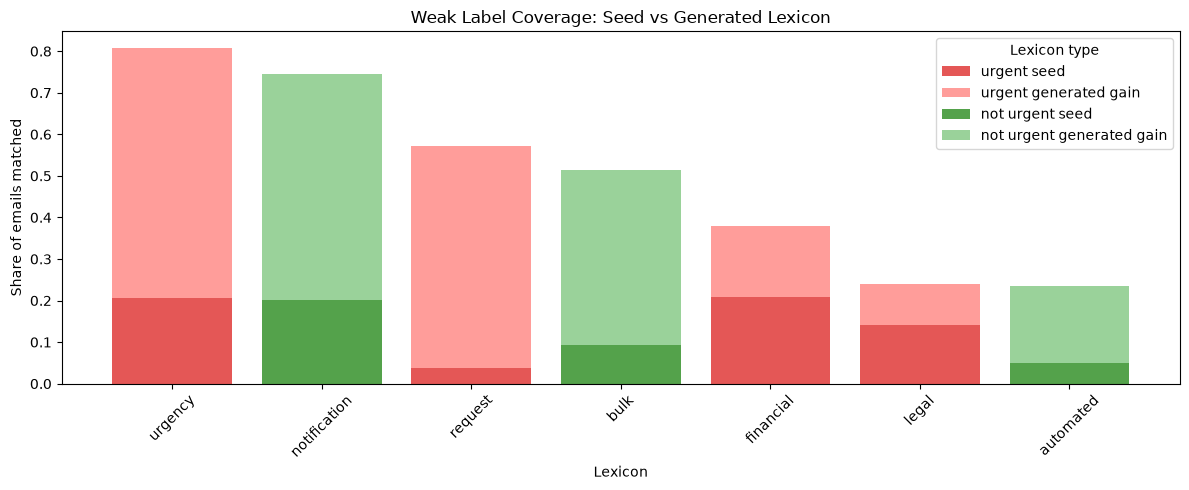

In [9]:
# lexicon coverage: seed coverage + added generated coverage
# Color family shows weak-label direction: urgent = red, not urgent = green.

import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = clean.copy()

lexicon_dir = Path("../lexicon")

LEXICON_LABELS = {
    "automated": "not urgent",
    "bulk": "not urgent",
    "notification": "not urgent",
    "financial": "urgent",
    "legal": "urgent",
    "request": "urgent",
    "urgency": "urgent",
}

text = (
    df["subject"].fillna("").astype(str)
    + " "
    + df["body"].fillna("").astype(str)
).str.lower()

def compile_terms_regex(terms: pd.Series):
    terms = terms.dropna().astype(str).str.lower().str.strip()
    terms = terms[terms.ne("")]
    if terms.empty:
        return None
    return re.compile(r"\b(?:%s)\b" % "|".join(re.escape(t) for t in terms), re.I)

coverage_rows = []

for path in sorted(lexicon_dir.glob("*.csv")):
    lexicon = pd.read_csv(path)

    if not {"prototype", "source"}.issubset(lexicon.columns):
        continue

    source = lexicon["source"].astype(str).str.lower()

    seed_re = compile_terms_regex(lexicon.loc[source.eq("seed"), "prototype"])
    seed_generated_re = compile_terms_regex(
        lexicon.loc[source.isin(["seed", "generated"]), "prototype"]
    )

    seed_match = (
        text.str.contains(seed_re, regex=True, na=False)
        if seed_re
        else pd.Series(False, index=df.index)
    )
    seed_generated_match = (
        text.str.contains(seed_generated_re, regex=True, na=False)
        if seed_generated_re
        else pd.Series(False, index=df.index)
    )

    seed_coverage = seed_match.mean()
    total_coverage = seed_generated_match.mean()

    coverage_rows.append(
        {
            "lexicon": path.stem,
            "label_type": LEXICON_LABELS.get(path.stem, "urgent"),
            "seed": seed_coverage,
            "generated_gain": total_coverage - seed_coverage,
            "total": total_coverage,
        }
    )

coverage = pd.DataFrame(coverage_rows).sort_values("total", ascending=False)

plot_df = coverage.set_index("lexicon")[["seed", "generated_gain"]]
label_lookup = coverage.set_index("lexicon")["label_type"]

colors = []
for lexicon in plot_df.index:
    if label_lookup.loc[lexicon] == "urgent":
        colors.append(["#E45756", "#FF9D9A"])   # red: seed, generated gain
    else:
        colors.append(["#54A24B", "#9AD29A"])   # green: seed, generated gain

fig, ax = plt.subplots(figsize=(12, 5))

bottom = pd.Series(0, index=plot_df.index, dtype=float)

for i, part in enumerate(["seed", "generated_gain"]):
    ax.bar(
        plot_df.index,
        plot_df[part],
        bottom=bottom,
        color=[c[i] for c in colors],
    )
    bottom += plot_df[part]

ax.set_title("Weak Label Coverage: Seed vs Generated Lexicon")
ax.set_xlabel("Lexicon")
ax.set_ylabel("Share of emails matched")
ax.tick_params(axis="x", rotation=45)

ax.legend(
    handles=[
        Patch(facecolor="#E45756", label="urgent seed"),
        Patch(facecolor="#FF9D9A", label="urgent generated gain"),
        Patch(facecolor="#54A24B", label="not urgent seed"),
        Patch(facecolor="#9AD29A", label="not urgent generated gain"),
    ],
    title="Lexicon type",
)

plt.tight_layout()
plt.show()

In [15]:
# labeling-function diagnostics:
# coverage, urgent/not-urgent LF signals, and gold-label overlap

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from configs.train_config import get_label_config
from src.emailurgency.models.labeler import WeakLabeler, URGENT, NOT_URGENT, ABSTAIN

df = clean.copy()

label_config = get_label_config()

embedding_model = SentenceTransformer(str(ROOT / label_config.embeddings_model))
embeddings = embedding_model.encode(
    df["body"].fillna("").astype(str).tolist(),
    **label_config.embeddings_params,
)

weaklabeler = WeakLabeler.load(ROOT / label_config.model_path)

X_lf = weaklabeler._add_semantic_features(df, embeddings)
LF = weaklabeler.applier.apply(X_lf, progress_bar=False)

has_gold = (
    df["gold_labels"].isin([0, 1])
    if "gold_labels" in df.columns
    else pd.Series(False, index=df.index)
)

gold_urgent = (
    df["gold_labels"].eq(1)
    if "gold_labels" in df.columns
    else pd.Series(False, index=df.index)
)

gold_not_urgent = (
    df["gold_labels"].eq(0)
    if "gold_labels" in df.columns
    else pd.Series(False, index=df.index)
)

lf_summary = []

for i, lf in enumerate(weaklabeler.lfs):
    votes = LF[:, i]
    covered = votes != ABSTAIN

    lf_summary.append(
        {
            "label_function": lf.name,

            "coverage_count": covered.sum(),
            "coverage_rate": covered.mean(),

            "urgent_signal_count": (votes == URGENT).sum(),
            "urgent_signal_rate": (votes == URGENT).mean(),

            "not_urgent_signal_count": (votes == NOT_URGENT).sum(),
            "not_urgent_signal_rate": (votes == NOT_URGENT).mean(),

            "gold_checked_count": (covered & has_gold.to_numpy()).sum(),
            "gold_not_checked_count": (~covered & has_gold.to_numpy()).sum(),

            "gold_urgent_checked_count": (covered & gold_urgent.to_numpy()).sum(),
            "gold_not_urgent_checked_count": (covered & gold_not_urgent.to_numpy()).sum(),

            "gold_urgent_not_checked_count": (~covered & gold_urgent.to_numpy()).sum(),
            "gold_not_urgent_not_checked_count": (~covered & gold_not_urgent.to_numpy()).sum(),
        }
    )

lf_summary = (
    pd.DataFrame(lf_summary)
    .sort_values("coverage_count", ascending=False)
    .reset_index(drop=True)
)

lf_summary

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6485.62it/s]


FileNotFoundError: Path artifacts/transformers/all-MiniLM-L6-v2 not found

In [ ]:
# list of emails that are mislabeled and include the labelfunction that signalled it